In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Ruta de los datos
DATA_PATH = Path("../data")

# Nombres de todos los archivos de sensores con su frecuencia de muestreo
SENSORS = {
    'PS1': 6000, 'PS2': 6000, 'PS3': 6000,
    'PS4': 6000, 'PS5': 6000, 'PS6': 6000,
    'EPS1': 6000,
    'FS1': 600,  'FS2': 600,
    'TS1': 60,   'TS2': 60,   'TS3': 60,   'TS4': 60,
    'VS1': 60,   'CE': 60,    'CP': 60,    'SE': 60
}

# Cargar cada sensor como DataFrame
sensor_data = {}
for sensor, freq in SENSORS.items():
    df = pd.read_csv(
        DATA_PATH / f"{sensor}.txt",
        sep="\t", # separado por tabs
        header=None, # no tiene fila de headers
    )
    sensor_data[sensor] = df
    print(f"{sensor}: shape = {df.shape}")
    
# Cargar targets
targets = pd.read_csv(
    DATA_PATH / "profile.txt",
    sep='\t',
    header=None,
    names=['cooler', 'valve', 'pump', 'accumulator', 'stable']
)

print(f"Targets: shape = {targets.shape}")
print(targets.head())

PS1: shape = (2205, 6000)
PS2: shape = (2205, 6000)
PS3: shape = (2205, 6000)
PS4: shape = (2205, 6000)
PS5: shape = (2205, 6000)
PS6: shape = (2205, 6000)
EPS1: shape = (2205, 6000)
FS1: shape = (2205, 600)
FS2: shape = (2205, 600)
TS1: shape = (2205, 60)
TS2: shape = (2205, 60)
TS3: shape = (2205, 60)
TS4: shape = (2205, 60)
VS1: shape = (2205, 60)
CE: shape = (2205, 60)
CP: shape = (2205, 60)
SE: shape = (2205, 60)
Targets: shape = (2205, 5)
   cooler  valve  pump  accumulator  stable
0       3    100     0          130       1
1       3    100     0          130       1
2       3    100     0          130       1
3       3    100     0          130       1
4       3    100     0          130       1


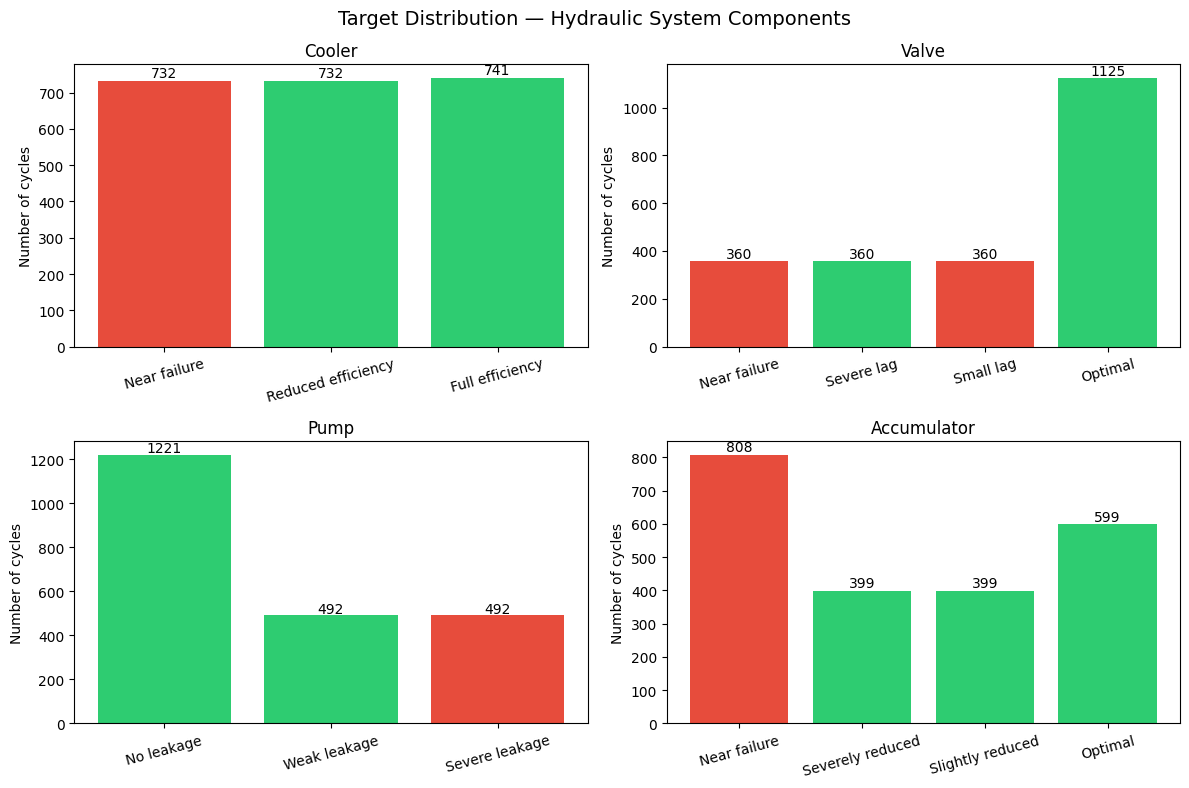


=== Class Distribution (%) ===

COOLER:
  Full efficiency: 33.6%
  Near failure: 33.2%
  Reduced efficiency: 33.2%

VALVE:
  Optimal: 51.0%
  Near failure: 16.3%
  Severe lag: 16.3%
  Small lag: 16.3%

PUMP:
  No leakage: 55.4%
  Severe leakage: 22.3%
  Weak leakage: 22.3%

ACCUMULATOR:
  Near failure: 36.6%
  Optimal: 27.2%
  Slightly reduced: 18.1%
  Severely reduced: 18.1%


In [5]:
# Ver distribución de cada componente
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Target Distribution — Hydraulic System Components', fontsize=14)

components = {
    'cooler': {3: 'Near failure', 20: 'Reduced efficiency', 100: 'Full efficiency'},
    'valve': {100: 'Optimal', 90: 'Small lag', 80: 'Severe lag', 73: 'Near failure'},
    'pump': {0: 'No leakage', 1: 'Weak leakage', 2: 'Severe leakage'},
    'accumulator': {130: 'Optimal', 115: 'Slightly reduced', 100: 'Severely reduced', 90: 'Near failure'}
}

for idx, (component, labels) in enumerate(components.items()):
    ax = axes[idx // 2][idx % 2]
    
    counts = targets[component].value_counts().sort_index()
    bars = ax.bar(
        [labels[k] for k in counts.index],
        counts.values,
        color=['#e74c3c' if k in [3, 73, 2, 90] else '#2ecc71' for k in counts.index]
    )
    
    # Agregar cantidad encima de cada barra
    for bar, count in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 10,
            str(count),
            ha='center', fontsize=10
        )
    
    ax.set_title(component.capitalize())
    ax.set_ylabel('Number of cycles')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../models/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Imprimir porcentajes
print("\n=== Class Distribution (%) ===")
for component in ['cooler', 'valve', 'pump', 'accumulator']:
    print(f"\n{component.upper()}:")
    dist = targets[component].value_counts(normalize=True) * 100
    for val, pct in dist.items():
        label = components[component][val]
        print(f"  {label}: {pct:.1f}%")

In [6]:
from scipy import stats

def extract_features(sensor_array):
    """
    Extrae estadísticas descriptivas de una serie temporal.
    Convierte N mediciones por ciclo en features numéricas usables por ML.
    
    Por qué estas estadísticas:
    - mean: valor promedio del sensor en el ciclo
    - std: variabilidad — una bomba fallando tiene más variabilidad de presión
    - min/max: valores extremos — una válvula atascada puede tener picos anómalos
    - range: diferencia entre max y min — indica amplitud de oscilación
    - rms: root mean square — métrica estándar en vibraciones industriales
    - skewness: asimetría de la distribución — fallas generan distribuciones asimétricas
    - kurtosis: curtosis — detecta outliers extremos, típicos en fallas mecánicas
    """
    return {
        'mean': np.mean(sensor_array),
        'std': np.std(sensor_array),
        'min': np.min(sensor_array),
        'max': np.max(sensor_array),
        'range': np.max(sensor_array) - np.min(sensor_array),
        'rms': np.sqrt(np.mean(sensor_array**2)),
        'skewness': stats.skew(sensor_array),
        'kurtosis': stats.kurtosis(sensor_array)
    }

# Construir DataFrame de features
print("Extracting features from all sensors...")
all_features = []

for cycle_idx in range(len(sensor_data['PS1'])):
    cycle_features = {}
    
    for sensor_name, sensor_df in sensor_data.items():
        # Obtener las mediciones del ciclo como array numpy
        cycle_measurements = sensor_df.iloc[cycle_idx].values
        
        # Extraer features estadísticas
        features = extract_features(cycle_measurements)
        
        # Agregar con prefijo del sensor para identificarlas
        for feat_name, feat_value in features.items():
            cycle_features[f"{sensor_name}_{feat_name}"] = feat_value
    
    all_features.append(cycle_features)

# Convertir a DataFrame
X = pd.DataFrame(all_features)

print(f"Feature matrix shape: {X.shape}")
print(f"Features por sensor: 8")
print(f"Total sensores: {len(SENSORS)}")
print(f"Total features: {X.shape[1]}")
print(f"\nPrimeras features:")
print(X.columns[:16].tolist())

Extracting features from all sensors...
Feature matrix shape: (2205, 136)
Features por sensor: 8
Total sensores: 17
Total features: 136

Primeras features:
['PS1_mean', 'PS1_std', 'PS1_min', 'PS1_max', 'PS1_range', 'PS1_rms', 'PS1_skewness', 'PS1_kurtosis', 'PS2_mean', 'PS2_std', 'PS2_min', 'PS2_max', 'PS2_range', 'PS2_rms', 'PS2_skewness', 'PS2_kurtosis']
